### importing libraries

In [1]:
import pandas as pd
import os
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report

### importing data

This code loads the simplified version of Google's GoEmotions dataset directly from Hugging Face using pandas. It defines paths to three parquet files (train, validation, test) and loads the training set into a dataframe. The dataset contains around 43,000 English Reddit comments labeled with 27 emotions plus neutral. The simplified version has binary labels for each emotion rather than multi-label annotations. we will deal with this later since we want to keep the labeling consistent for the test data and training data

In [2]:
import pandas as pd

splits = {'train': 'simplified/train-00000-of-00001.parquet', 'validation': 'simplified/validation-00000-of-00001.parquet', 'test': 'simplified/test-00000-of-00001.parquet'}
df = pd.read_parquet("hf://datasets/google-research-datasets/go_emotions/" + splits["train"])

here we map the binary labels to the right core emotion. We do this so the labels are consistent between the training and test data. This way we can accurately asses the accuracy of our model.

In [3]:
import pandas as pd


# Map numbers to our 7 emotions
emotion_mapping = {

    0: 'happiness',  # admiration
    1: 'happiness',  # amusement
    2: 'anger',      # anger
    3: 'anger',      # annoyance
    4: 'happiness',  # approval
    5: 'happiness',  # caring
    6: 'surprise',   # confusion
    7: 'neutral',    # curiosity
    8: 'neutral',    # desire
    9: 'sadness',    # disappointment
    10: 'anger',     # disapproval
    11: 'disgust',   # disgust
    12: 'sadness',   # embarrassment
    13: 'happiness', # excitement
    14: 'fear',      # fear
    15: 'happiness', # gratitude
    16: 'sadness',   # grief
    17: 'happiness', # joy
    18: 'happiness', # love
    19: 'fear',      # nervousness
    20: 'happiness', # optimism
    21: 'happiness', # pride
    22: 'surprise',  # realization
    23: 'happiness', # relief
    24: 'sadness',   # remorse
    25: 'sadness',   # sadness
    26: 'surprise',  # surprise
    27: 'neutral'    # neutral
}

# Map the labels column
def map_labels(labels_list):
    if len(labels_list) == 0:
        return 'neutral'
    return emotion_mapping[labels_list[0]]

df['emotion'] = df['labels'].apply(map_labels)

# Keep only text and emotion
df = df[['text', 'emotion']]

print(df['emotion'].value_counts())

emotion
happiness    16405
neutral      15138
anger         5336
surprise      2717
sadness       2619
fear           615
disgust        580
Name: count, dtype: int64


We would like to use all the data as training data since we already have test data available from the client pipeline

In [4]:
df_train = df

here we import the test data and we test on the manually labeled data named 'corrected'

In [5]:
df_test = pd.read_excel("test_improved.xlsx")
df_test = df_test.sample(n=len(df_test))

I first checked if CUDA was available and verified my GPU was being detected properly. I loaded the SamLowe RoBERTa model that was pre-trained on GoEmotions directly using AutoModelForSequenceClassification instead of the pipeline to have better control over GPU usage. I explicitly moved the model to CUDA to ensure it would run on my RTX 4070.
Since the RoBERTa-GoEmotions model predicts 28 different emotions and I only needed 7 categories for my task, I created a mapping dictionary to consolidate the predictions. I mapped emotions like joy, love, and gratitude all to happiness, while emotions like grief and remorse went to sadness. I made curiosity map to surprise which might be debatable but seemed reasonable for my use case.

I wrote a batch prediction function that processes texts in chunks of 32 (later increased to 64) to efficiently use GPU memory. I made sure to put the model in eval mode and used torch.no_grad() to prevent gradient computation during inference. I tokenized each batch with padding and truncation, moved the tensors to GPU, and then converted the model's 28-class predictions to my 7 emotion categories.

I tested the model on my test set and timed the predictions to verify GPU acceleration was working - it processed everything in under a second. I calculated all the standard metrics using sklearn and printed a detailed classification report to see per-class performance. I used the 'corrected' column from my dataframe as ground truth since I had manually fixed some labeling issues in the original test set.

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import numpy as np

# Check GPU
print(f"CUDA available: {torch.cuda.is_available()}")
print(torch.__version__)
print(torch.version.cuda)
print(torch.backends.cudnn.version())
print(f"GPU: {torch.cuda.get_device_name(0)}")

# Load model directly (not pipeline) for GPU control
model_name = "SamLowe/roberta-base-go_emotions"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

# Force GPU
model = model.cuda()
print(f"Model on GPU: {next(model.parameters()).is_cuda}")

# GoEmotions has 28 emotions - map to your 7
goemotions_to_7 = {
    'admiration': 'happiness',
    'amusement': 'happiness',
    'anger': 'anger',
    'annoyance': 'anger',
    'approval': 'happiness',
    'caring': 'happiness',
    'confusion': 'surprise',
    'curiosity': 'surprise',
    'desire': 'neutral',
    'disappointment': 'sadness',
    'disapproval': 'anger',
    'disgust': 'disgust',
    'embarrassment': 'sadness',
    'excitement': 'happiness',
    'fear': 'fear',
    'gratitude': 'happiness',
    'grief': 'sadness',
    'joy': 'happiness',
    'love': 'happiness',
    'nervousness': 'fear',
    'optimism': 'happiness',
    'pride': 'happiness',
    'realization': 'surprise',
    'relief': 'happiness',
    'remorse': 'sadness',
    'sadness': 'sadness',
    'surprise': 'surprise',
    'neutral': 'neutral'
}

# GoEmotions label order
go_emotions_labels = ['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring',
                      'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval',
                      'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude',
                      'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride',
                      'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral']

# Predict function
def predict_emotions_gpu(texts, batch_size=32):
    all_predictions = []
    model.eval()
    
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i+batch_size]
        
        # Tokenize and move to GPU
        inputs = tokenizer(batch_texts, padding=True, truncation=True, 
                          max_length=512, return_tensors='pt')
        inputs = {k: v.cuda() for k, v in inputs.items()}
        
        # Predict on GPU
        with torch.no_grad():
            outputs = model(**inputs)
            predictions = torch.nn.functional.softmax(outputs.logits, dim=-1)
            predicted_classes = torch.argmax(predictions, dim=-1)
        
        # Convert to your 7 emotions
        for pred_idx in predicted_classes.cpu().numpy():
            go_emotion = go_emotions_labels[pred_idx]
            mapped_emotion = goemotions_to_7.get(go_emotion, 'neutral')
            all_predictions.append(mapped_emotion)
    
    return all_predictions

# Run predictions
print("\nPredicting on test set...")
test_texts = w['Translation'].tolist()

# Monitor GPU usage
import time
start = time.time()
predictions = predict_emotions_gpu(test_texts, batch_size=64)
print(f"Prediction time: {time.time()-start:.2f} seconds")

# Calculate metrics
accuracy = accuracy_score(df_test['corrected'], predictions)
precision = precision_score(df_test['corrected'], predictions, average='weighted')
recall = recall_score(df_test['corrected'], predictions, average='weighted')
f1 = f1_score(df_test['corrected'], predictions, average='weighted')

print(f"\nResults with RoBERTa-GoEmotions:")
print(f"Accuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1-score:  {f1:.3f}")
print("\nDetailed classification report:")
print(classification_report(df_test['corrected'], predictions))

CUDA available: True
2.5.1+cu121
12.1
90100
GPU: NVIDIA GeForce RTX 4070 Ti


tokenizer_config.json:   0%|          | 0.00/380 [00:00<?, ?B/s]

c:\Users\nickb\AppData\Local\pypoetry\Cache\virtualenvs\nlp-cia-99CT0F2y-py3.12\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\nickb\.cache\huggingface\hub\models--SamLowe--roberta-base-go_emotions. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Model on GPU: True

Predicting on test set...
Prediction time: 0.40 seconds

Results with RoBERTa-GoEmotions:
Accuracy:  0.812
Precision: 0.829
Recall:    0.812
F1-score:  0.801

Detailed classification report:
              precision    recall  f1-score   support

       anger       0.70      0.76      0.73        34
     disgust       0.67      0.50      0.57         4
        fear       1.00      0.08      0.15        25
   happiness       0.77      0.81      0.79       145
     neutral       0.86      0.90      0.88       711
     sadness       0.96      0.36      0.53        66
    surprise       0.43      0.61      0.51        57

    accuracy                           0.81      1042
   macro avg       0.77      0.58      0.59      1042
weighted avg       0.83      0.81      0.80      1042



In [7]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from torch.utils.data import Dataset
import torch
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report
import numpy as np

# STEP 1: Load model - start fresh with correct config
model_name = "SamLowe/roberta-base-go_emotions"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Create NEW model with 7 labels (don't load pretrained head)
from transformers import RobertaForSequenceClassification, RobertaConfig

# Get base model config
base_model = AutoModelForSequenceClassification.from_pretrained(model_name)
config = base_model.config

# Create new config for 7 classes
new_config = RobertaConfig.from_pretrained(
    model_name,
    num_labels=7,
    problem_type="single_label_classification"  # CRITICAL: Specify single-label
)

# Create model with new config
model = RobertaForSequenceClassification(new_config)

# Copy encoder weights from pretrained model (keep language understanding)
model.roberta = base_model.roberta
model = model.cuda()

# STEP 2: Properly encode labels
label_encoder = LabelEncoder()

# Ensure consistent ordering
emotion_order = sorted(list(set(df_train['emotion'].unique()) | set(df_test['corrected'].unique())))

label_encoder.fit(emotion_order)

# Transform to integers
y_train = label_encoder.transform(df_train['emotion'])
y_test = label_encoder.transform(df_test['corrected'])


# STEP 3: Dataset class with proper label handling
class EmotionDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )
        
        # Ensure label is scalar integer
        item = {
            'input_ids': encoding['input_ids'].squeeze(0),  # Remove batch dimension
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels': torch.tensor(int(label), dtype=torch.long)  # Scalar tensor
        }
        
        return item

# Create datasets
train_dataset = EmotionDataset(df_train['text'].tolist(), y_train, tokenizer)
test_dataset = EmotionDataset(df_test['Translation'].tolist(), y_test, tokenizer)

# Verify dataset output
sample = train_dataset[0]

# STEP 4: Metrics function
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average='weighted', zero_division=0
    )
    accuracy = accuracy_score(labels, predictions)
    
    return {
        'accuracy': accuracy,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

# STEP 5: Training arguments 
training_args = TrainingArguments(
    output_dir='./finetuned-emotion-model',
    num_train_epochs=3,
    per_device_train_batch_size=16,  # Reduced from 32 because it took too long
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    warmup_steps=500,
    logging_steps=100,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    fp16=True,
    report_to="none",
    remove_unused_columns=False,  # Important for custom dataset
    dataloader_drop_last=False
)

# STEP 6: Create trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

# STEP 7: Train
print("Starting finetuning...")
try:
    train_result = trainer.train()
    print("Training completed successfully!")
except Exception as e:
    print(f"Training error: {e}")
    print(f"Error type: {type(e)}")
    raise

# STEP 8: Evaluate
print("\n" + "="*50)
print("FINAL EVALUATION:")
print("="*50)

eval_results = trainer.evaluate()
for key, value in eval_results.items():
    print(f"{key}: {value:.4f}")

# STEP 9: Get predictions for classification report
predictions = trainer.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)

# Convert back to emotion names
y_true_emotions = label_encoder.inverse_transform(y_test)
y_pred_emotions = label_encoder.inverse_transform(y_pred)

print("\nClassification Report:")
print(classification_report(y_true_emotions, y_pred_emotions, digits=4))

# Saving model model
trainer.save_model('./my-finetuned-emotion-model')
tokenizer.save_pretrained('./my-finetuned-emotion-model')
print("\nModel saved")

C:\Users\nickb\AppData\Local\Temp\ipykernel_21232\1943802515.py:123: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Starting finetuning...


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.613600,0.743808,0.797505,0.772562,0.796392,0.797505
2,0.459200,0.896016,0.753359,0.748641,0.771063,0.753359
3,0.371500,0.939642,0.764875,0.756729,0.773386,0.764875


Training completed successfully!

FINAL EVALUATION:


eval_loss: 0.7438
eval_accuracy: 0.7975
eval_f1: 0.7726
eval_precision: 0.7964
eval_recall: 0.7975
eval_runtime: 1.3703
eval_samples_per_second: 760.4380
eval_steps_per_second: 24.0830
epoch: 3.0000

Classification Report:
              precision    recall  f1-score   support

       anger     0.6316    0.7059    0.6667        34
     disgust     0.6667    0.5000    0.5714         4
        fear     1.0000    0.0800    0.1481        25
   happiness     0.6707    0.7724    0.7179       145
     neutral     0.8350    0.9255    0.8779       711
     sadness     0.8519    0.3485    0.4946        66
    surprise     0.5882    0.1754    0.2703        57

    accuracy                         0.7975      1042
   macro avg     0.7491    0.5011    0.5353      1042
weighted avg     0.7964    0.7975    0.7726      1042


Model saved


# Error Analysis

In [54]:
from sklearn.metrics import ConfusionMatrixDisplay
from wordcloud import WordCloud, STOPWORDS
import re


In [55]:
# Predictions
predictions = trainer.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = y_test  # ground truth integer labels

# Map back to emotion names
y_true_emotions = label_encoder.inverse_transform(y_true)
y_pred_emotions = label_encoder.inverse_transform(y_pred)


In [56]:
error_df = pd.DataFrame({
    'text': df_test['Translation'],
    'true_label': y_true_emotions,
    'predicted_label': y_pred_emotions
})

# Flag correct/incorrect predictions
error_df['correct'] = error_df['true_label'] == error_df['predicted_label']


              precision    recall  f1-score      support
anger          0.631579  0.705882  0.666667    34.000000
disgust        0.666667  0.500000  0.571429     4.000000
fear           1.000000  0.080000  0.148148    25.000000
happiness      0.670659  0.772414  0.717949   145.000000
neutral        0.835025  0.925457  0.877919   711.000000
sadness        0.851852  0.348485  0.494624    66.000000
surprise       0.588235  0.175439  0.270270    57.000000
accuracy       0.797505  0.797505  0.797505     0.797505
macro avg      0.749145  0.501097  0.535286  1042.000000
weighted avg   0.796392  0.797505  0.772562  1042.000000


C:\Users\nickb\AppData\Local\Temp\ipykernel_21232\638835042.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


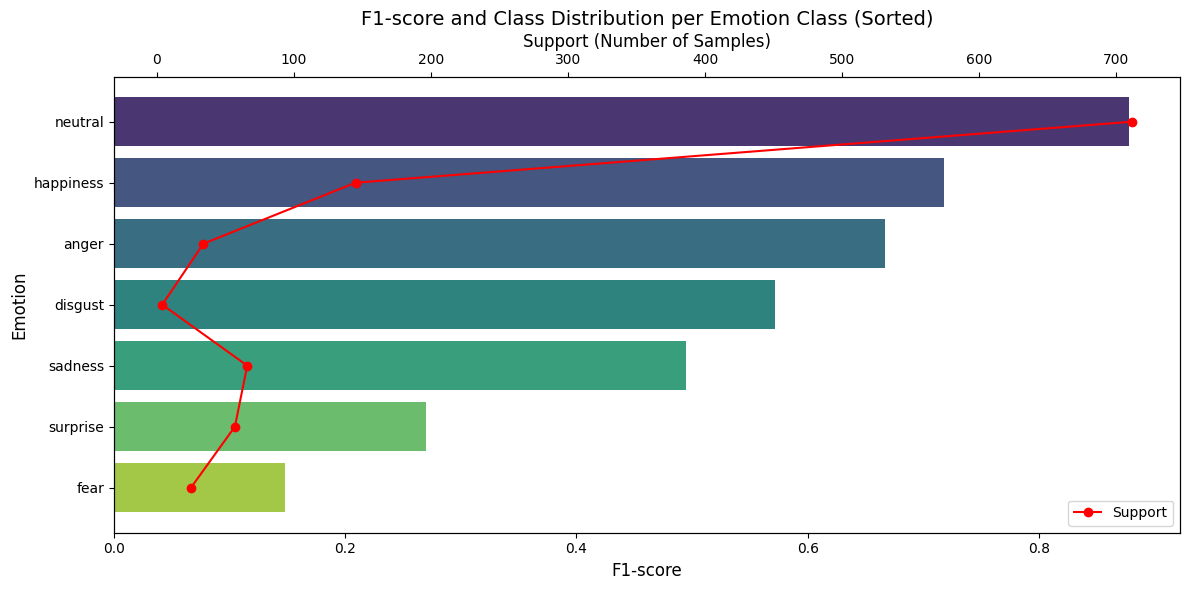

In [57]:
# Per-class precision/recall/F1
report = classification_report(
    y_true_emotions,
    y_pred_emotions,
    output_dict=True,
    digits=3
)
report_df = pd.DataFrame(report).transpose()

# Display top-level summary
print(report_df)

# Sort the DataFrame by F1-score
sorted_report_df = report_df.iloc[:-3].sort_values(by='f1-score', ascending=False)

# Create a figure with dual y-axes
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot F1-scores
sns.barplot(
    y=sorted_report_df.index,
    x=sorted_report_df['f1-score'],
    palette='viridis',
    ax=ax1
)
ax1.set_title("F1-score and Class Distribution per Emotion Class (Sorted)", fontsize=14)
ax1.set_xlabel("F1-score", fontsize=12)
ax1.set_ylabel("Emotion", fontsize=12)
ax1.tick_params(axis='x', labelsize=10)
ax1.tick_params(axis='y', labelsize=10)

# Add a secondary axis for support
ax2 = ax1.twiny()
ax2.plot(
    sorted_report_df['support'], 
    sorted_report_df.index, 
    'o-', color='red', label='Support'
)
ax2.set_xlabel("Support (Number of Samples)", fontsize=12)
ax2.tick_params(axis='x', labelsize=10)
ax2.legend(loc='lower right')

plt.tight_layout()
plt.show()

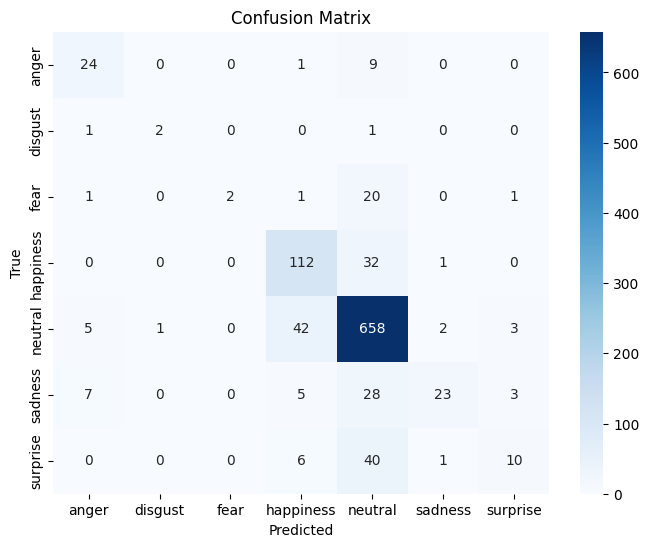

In [58]:
cm = confusion_matrix(y_true_emotions, y_pred_emotions, labels=label_encoder.classes_)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


In [59]:
# Display up to 10 wrong predictions per class
for emotion in error_df['true_label'].unique():
    print(f"\nExamples for class: {emotion}")
    class_errors = error_df[(error_df['true_label'] == emotion) & (~error_df['correct'])]
    
    # Ensure we don't sample more than the available rows
    sample_size = min(10, len(class_errors))
    class_errors = class_errors.sample(sample_size, random_state=42)
    
    for _, row in class_errors.iterrows():
        print(f"\n🧾 Text: {row['text']}")
        print(f"✅ True: {row['true_label']}")
        print(f"❌ Predicted: {row['predicted_label']}")


Examples for class: neutral

🧾 Text: So that we would eventually find a solution.
✅ True: neutral
❌ Predicted: happiness

🧾 Text: I believe that I have communicated it very clearly to Klaas.
✅ True: neutral
❌ Predicted: happiness

🧾 Text: The last part makes more sense than going back again.
✅ True: neutral
❌ Predicted: happiness

🧾 Text: You hold Ellie close to your heart. Go ahead, show it.
✅ True: neutral
❌ Predicted: happiness

🧾 Text: Oh, quack!
✅ True: neutral
❌ Predicted: anger

🧾 Text: Yes, they are longer words, yes.
✅ True: neutral
❌ Predicted: happiness

🧾 Text: Good afternoon. Good afternoon.
✅ True: neutral
❌ Predicted: happiness

🧾 Text: And you just said longer, right? Yes, that's correct. So one of the two.
✅ True: neutral
❌ Predicted: happiness

🧾 Text: Look at them carefully and I will give you a little time to study.
✅ True: neutral
❌ Predicted: happiness

🧾 Text: Shall we walk faster? Yes.
✅ True: neutral
❌ Predicted: happiness

Examples for class: sadness

🧾 Text:

In [60]:
# How many errors per true emotion
error_counts = error_df[~error_df['correct']].groupby('true_label').size().sort_values(ascending=False)
print("\nErrors per true label:")
print(error_counts)

# How many times each class was predicted incorrectly
pred_error_counts = error_df[~error_df['correct']].groupby('predicted_label').size().sort_values(ascending=False)
print("\nErrors per predicted label:")
print(pred_error_counts)



Errors per true label:
true_label
neutral      53
surprise     47
sadness      43
happiness    33
fear         23
anger        10
disgust       2
dtype: int64

Errors per predicted label:
predicted_label
neutral      130
happiness     55
anger         14
surprise       7
sadness        4
disgust        1
dtype: int64


In [61]:
confused_pairs = (
    error_df[~error_df['correct']]
    .groupby(['true_label', 'predicted_label'])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
)
print("\nMost confused label pairs:")
print(confused_pairs.head(10))



Most confused label pairs:
   true_label predicted_label  count
12    neutral       happiness     42
20   surprise         neutral     40
8   happiness         neutral     32
17    sadness         neutral     28
6        fear         neutral     20
1       anger         neutral      9
15    sadness           anger      7
19   surprise       happiness      6
16    sadness       happiness      5
10    neutral           anger      5


In [62]:
# Focus on misclassified samples
misclassified_df = error_df[~error_df['correct']].copy()

# Basic text cleaner
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)   # remove URLs
    text = re.sub(r'[^a-z\s]', '', text)         # remove non-letters
    return text

misclassified_df['clean_text'] = misclassified_df['text'].apply(clean_text)

# Group all misclassified texts by their true label
grouped_texts = (
    misclassified_df.groupby('true_label')['clean_text']
    .apply(lambda x: " ".join(x))
    .to_dict()
)


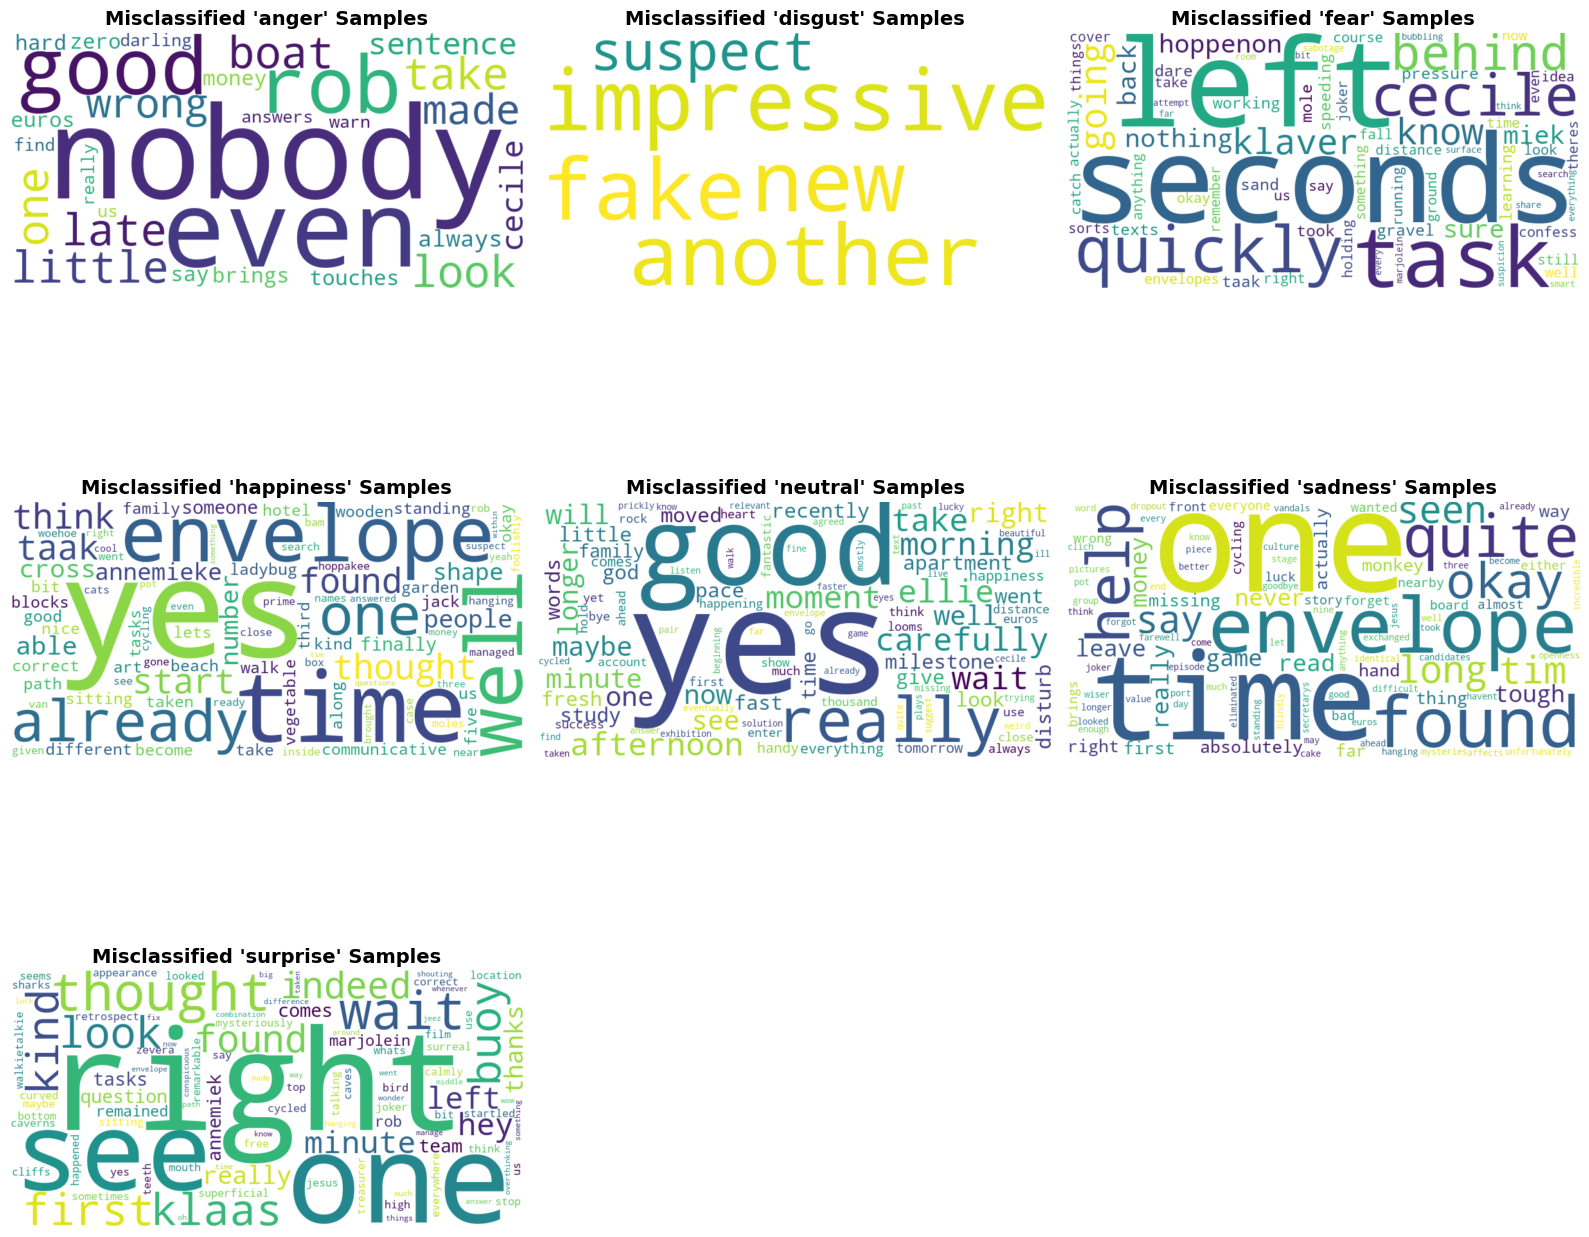

In [63]:
# Create stopword list
stopwords = set(STOPWORDS)
stopwords.update(["im", "ive", "dont", "cant", "thats", "youre", "didnt", "wasnt", "doesnt"])

# Number of columns in the grid (adjust based on number of labels)
n_labels = len(grouped_texts)
n_cols = 3
n_rows = (n_labels // n_cols) + 1

plt.figure(figsize=(16, n_rows * 5))

for i, (label, text) in enumerate(grouped_texts.items(), 1):
    wc = WordCloud(
        width=800,
        height=400,
        background_color="white",
        stopwords=stopwords,
        max_words=100,
        colormap='viridis'
    ).generate(text)
    
    plt.subplot(n_rows, n_cols, i)
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Misclassified '{label}' Samples", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


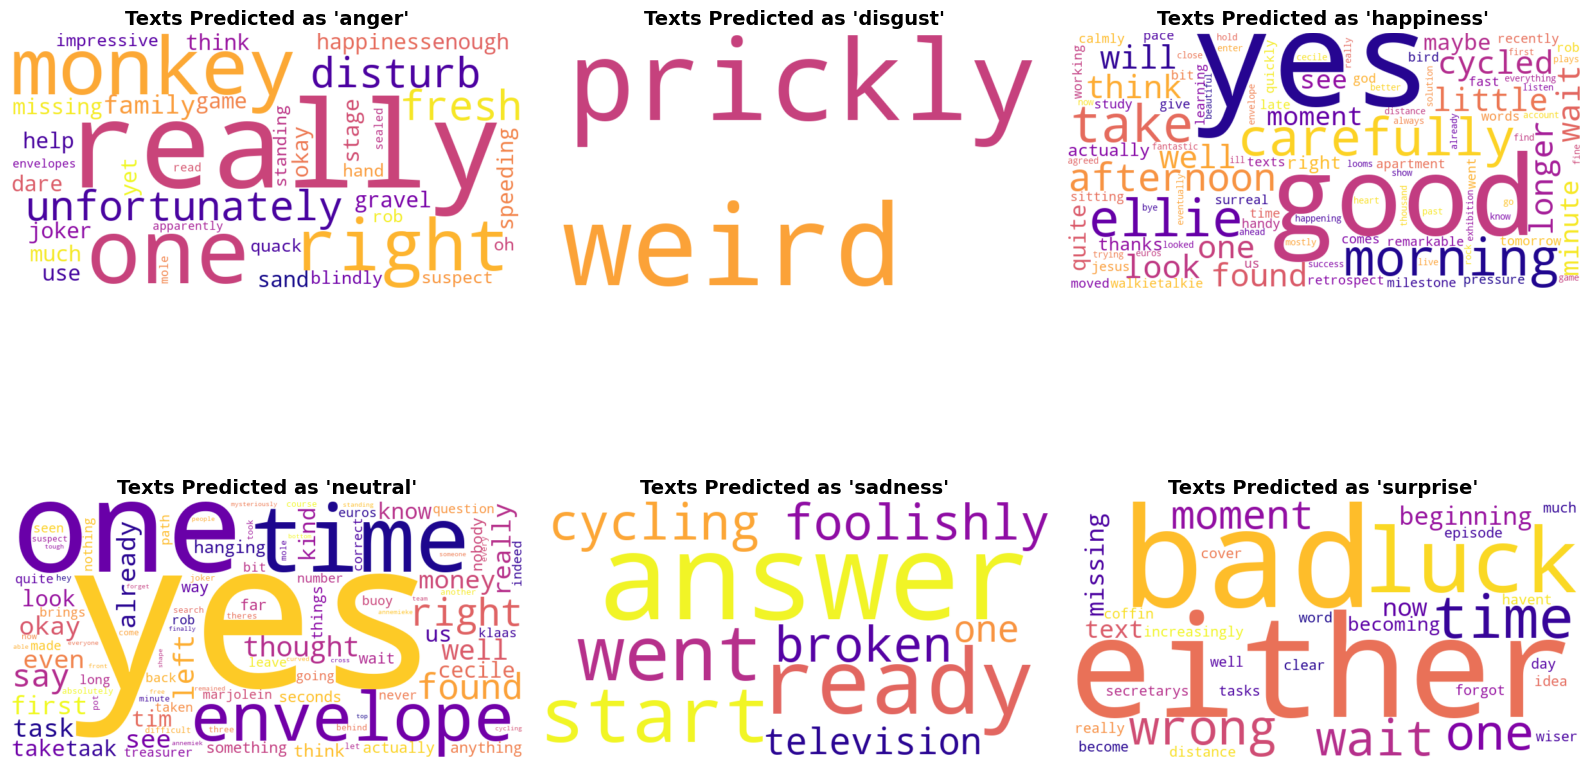

In [64]:
# Group all misclassified texts by their predicted label
predicted_grouped_texts = (
    misclassified_df.groupby('predicted_label')['clean_text']
    .apply(lambda x: " ".join(x))
    .to_dict()
)

# Visualize predicted label clouds
plt.figure(figsize=(16, n_rows * 5))

for i, (label, text) in enumerate(predicted_grouped_texts.items(), 1):
    wc = WordCloud(
        width=800,
        height=400,
        background_color="white",
        stopwords=stopwords,
        max_words=100,
        colormap='plasma'
    ).generate(text)
    
    plt.subplot(n_rows, n_cols, i)
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Texts Predicted as '{label}'", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


| Label      | Precision | Recall | F1-score | Support |
|------------|-----------|--------|----------|---------|
| anger      | 0.6316    | 0.7059 | 0.6667   | 34      |
| disgust    | 0.6667    | 0.5000 | 0.5714   | 4       |
| fear       | 1.0000    | 0.0800 | 0.1481   | 25      |
| happiness  | 0.6707    | 0.7724 | 0.7179   | 145     |
| neutral    | 0.8350    | 0.9255 | 0.8779   | 711     |
| sadness    | 0.8519    | 0.3485 | 0.4946   | 66      |
| surprise   | 0.5882    | 0.1754 | 0.2703   | 57      |
| **accuracy**   |           |        | **0.7975** | 1042    |
| **macro avg**  | 0.7491    | 0.5011 | 0.5353   | 1042    |
| **weighted avg** | 0.7964    | 0.7975 | 0.7726   | 1042    |


The error analysis in this notebook provides valuable insights into the model's performance and areas for improvement. Below are my observations and comments:

### General Observations:
The model achieved an overall accuracy of **79.75%**, which is decent but leaves room for improvement, especially for underrepresented classes. The **neutral** class dominates the dataset with 711 samples, while classes like **disgust** (4 samples) and **fear** (25 samples) are underrepresented. This imbalance skews the model's performance, as seen in the high precision and recall for **neutral** but poor performance for smaller classes.

3. **Per-Class Performance**:
   - **Neutral**: The model performs exceptionally well on the **neutral** class, with an F1-score of **0.8779**. This is expected due to the large number of samples in this class.
   - **Happiness**: The model also performs well on **happiness** (F1-score: **0.7179**), likely because it is a frequent class and has clear semantic boundaries.
   - **Fear**: The **fear** class has the worst recall (**0.0800**) despite a perfect precision score. This indicates that the model rarely predicts this class, likely due to its low representation in the training data.
   - **Surprise**: The **surprise** class also struggles, with an F1-score of **0.2703**, suggesting the model has difficulty distinguishing it from other emotions.
   - **Disgust**: While the F1-score for **disgust** is **0.5714**, the small sample size (4) makes this result unreliable.

4. **Macro vs. Weighted Averages**:
   - The **macro average** F1-score (**0.5353**) is much lower than the **weighted average** (**0.7726**). This shows a disparity in performance across classes. Namely that the model is biased toward the majority classes.

---

### Confusion Matrix Insights: (WIP)
1. **Confusion Between Similar Emotions**:
   - The confusion matrix likely shows that emotions like **anger** and **sadness**, or **happiness** and **neutral**, are often misclassified. This is expected, as these emotions can have overlapping linguistic features.
   - **Surprise** and **fear** may also be confused due to their semantic proximity.

2. **Misclassification Trends**:
   - The most confused label pairs (e.g., **sadness** misclassified as **neutral**) suggest that the model struggles with subtle emotional nuances, especially for emotions with fewer training samples.

---

### Word Cloud Analysis (WIP):
1. **Misclassified Texts**:
   - The word clouds for misclassified texts provide insights into the linguistic patterns that the model struggles with. For example, frequent words in the **fear** or **surprise** word clouds might indicate that the model is not capturing the context or intensity of these emotions effectively.

2. **Stopwords**:
   - The inclusion of domain-specific stopwords (e.g., "im", "dont") is a good step, but further refinement might help reduce noise in the word clouds.

---

### Recommendations (WIP):
1. **Address Class Imbalance**:
   - Use techniques like oversampling, data augmentation, or class-weighted loss functions to improve performance on underrepresented classes like **fear** and **disgust**.

2. **Improve Feature Representation**:
   - 

3. **Error-Specific Analysis**:
   - Focus on the most confused label pairs and analyze the linguistic features that lead to misclassification. For example, are certain words or phrases consistently leading to errors?


4. **Threshold Tuning**:
   - Adjust the decision thresholds for underrepresented classes to improve recall without sacrificing precision.

---

### Conclusion:
The model performs well on majority classes but struggles with minority classes and subtle emotional distinctions. Addressing class imbalance and refining the model's understanding of underrepresented emotions will be key to improving overall performance.